<a href="https://colab.research.google.com/github/23200110-bit/Reto2_Robotica/blob/main/Copia_de_CapyTown_Deteccion_Lineas_LiDAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extracción de líneas a partir de datos LiDAR / láser
### Capítulo 4.7 — *Introduction to Autonomous Mobile Robots* (Siegwart, Nourbakhsh & Scaramuzza)

**Curso:** Robótica de Robots Móviles · Proyecto **CapyTown** (ROS2 + Yahboom Pi5)

Un escáner LiDAR 2D entrega un conjunto de medidas $(\theta_i, \rho_i)$: para cada ángulo $\theta_i$ devuelve la distancia $\rho_i$ al primer obstáculo. En entornos hechos por el ser humano (paredes, pasillos, las "manzanas" de CapyTown) esas medidas caen en su mayoría sobre **segmentos de recta**. Detectar esas líneas es la base de:

- **Localización** del robot (¿dónde estoy respecto a las paredes?),
- **Construcción de mapas** (SLAM),
- **Evitación de obstáculos** y navegación.

El problema de extracción de líneas responde a **tres preguntas** (Siegwart §4.7):

1. ¿**Cuántas** líneas hay?
2. ¿**Qué puntos** pertenecen a cada línea?
3. Dados los puntos de una línea, ¿cómo **estimar los parámetros** del modelo de recta?

Empezaremos por la pregunta 3 (*line fitting*), porque las 6 algoritmos de segmentación la usan internamente. Luego veremos los **seis algoritmos** del libro para responder las preguntas 1 y 2.

> **Cómo usar este notebook:** ejecuta las celdas en orden (`Shift+Enter`). Cada algoritmo trae su pseudocódigo del libro, una implementación en Python comentada y una demostración visual. Al final hay ejercicios y la conexión con el tópico `/scan` de ROS2.

In [ ]:
# Librerías base
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)          # reproducibilidad
plt.rcParams['figure.figsize'] = (7, 7)
plt.rcParams['figure.dpi'] = 100

def set_eje_igual(ax):
    '''Mantiene la escala 1:1 para que las rectas se vean con su ángulo real.'''
    ax.set_aspect('equal', 'box')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
print('Entorno listo.')

Entorno listo.


## 1. Cómo representamos una recta: forma polar $(\alpha, r)$

En robótica una recta NO se representa como $y = mx + b$ (la pendiente $m$ se vuelve infinita para paredes verticales). Se usa la **forma normal / polar**:

$$x\cos\alpha + y\sin\alpha = r$$

donde:
- $r \ge 0$ es la **distancia perpendicular** del origen (el robot) a la recta,
- $\alpha$ es el **ángulo** de esa perpendicular respecto al eje $x$.

Cualquier recta del plano queda descrita por dos números $(\alpha, r)$, sin singularidades. La **distancia perpendicular** de un punto $(x_0,y_0)$ a la recta es:

$$d = x_0\cos\alpha + y_0\sin\alpha - r$$

Este $d$ es el "error" que casi todos los algoritmos intentan minimizar.

In [ ]:
def punto_polar_a_cartesiano(theta, rho):
    '''Convierte una medida LiDAR (ang, dist) -> (x, y).'''
    return rho*np.cos(theta), rho*np.sin(theta)

def distancia_punto_recta(x, y, alpha, r):
    '''Distancia perpendicular (con signo) de (x,y) a la recta (alpha, r).'''
    return x*np.cos(alpha) + y*np.sin(alpha) - r

def dibujar_recta(ax, alpha, r, x_rango, **kw):
    '''Dibuja la recta x*cos(a)+y*sin(a)=r dentro de un rango de x.'''
    xs = np.array(x_rango)
    if abs(np.sin(alpha)) > 1e-9:
        ys = (r - xs*np.cos(alpha)) / np.sin(alpha)
        ax.plot(xs, ys, **kw)
    else:  # recta casi vertical
        ax.axvline(r/np.cos(alpha), **kw)

## 2. *Line fitting*: ajuste de recta por mínimos cuadrados (pregunta 3)

Tenemos $n$ puntos que (suponemos) pertenecen a una recta, pero con ruido de medida. Buscamos $(\alpha, r)$ que **minimicen la suma de las distancias perpendiculares al cuadrado**:

$$S = \sum_i d_i^2 = \sum_i \big(x_i\cos\alpha + y_i\sin\alpha - r\big)^2$$

Esto se llama **total least squares** (mínimos cuadrados totales) porque mide el error *perpendicular* a la recta, no vertical. Resolviendo $\partial S/\partial\alpha = 0$ y $\partial S/\partial r = 0$ se obtiene la **solución cerrada** del libro (ecuaciones 4.136 y 4.137):

$$\alpha = \frac{1}{2}\operatorname{atan2}\!\Big(-2\sum_i (\bar x - x_i)(\bar y - y_i),\;\; \sum_i\big[(\bar y - y_i)^2 - (\bar x - x_i)^2\big]\Big)$$

$$r = \bar x\cos\alpha + \bar y\sin\alpha$$

donde $\bar x, \bar y$ son los centroides. Si cada medida tiene una incertidumbre distinta, se ponderan con $w_i = 1/\sigma_i^2$ (versión ponderada, ec. 4.135). Implementamos la versión ponderada (con pesos iguales = no ponderada).

In [ ]:
def ajustar_recta_ls(x, y, w=None):
    '''
    Ajuste total-least-squares de una recta en forma polar (alpha, r).
    Implementa las ecuaciones 4.136 y 4.137 de Siegwart (versión ponderada).
    x, y : arrays de coordenadas de los puntos
    w    : pesos opcionales (1/sigma^2). Si es None -> pesos iguales.
    Devuelve (alpha, r).
    '''
    x = np.asarray(x, float); y = np.asarray(y, float)
    if w is None:
        w = np.ones_like(x)
    W = w.sum()
    xb = np.sum(w*x)/W          # centroide ponderado en x
    yb = np.sum(w*y)/W          # centroide ponderado en y
    dx = xb - x
    dy = yb - y
    num = -2.0*np.sum(w*dx*dy)
    den = np.sum(w*(dy**2 - dx**2))
    alpha = 0.5*np.arctan2(num, den)
    r = xb*np.cos(alpha) + yb*np.sin(alpha)
    if r < 0:                   # convención r >= 0
        r = -r
        alpha = alpha + np.pi
    return alpha, r

### 2.1 Ejemplo concreto del libro (Tabla 4.3)

El libro presenta **17 medidas** tomadas por un sensor láser sobre un robot móvil (Tabla 4.3). El ángulo va de 0° a 80° en pasos de 5°. Aplicando las ecuaciones se obtiene la recta $\alpha = 37.36°$, $r = 0.4\,$m (Figura 4.89). Vamos a reproducirlo.

In [ ]:
# --- Tabla 4.3 del libro: 17 medidas (theta en grados, rho en metros) ---
theta_deg = np.arange(0, 85, 5)   # 0,5,10,...,80
rho = np.array([0.5197, 0.4404, 0.4850, 0.4222, 0.4132, 0.4371, 0.3912,
                0.3949, 0.3919, 0.4276, 0.4075, 0.3956, 0.4053, 0.4752,
                0.5032, 0.5273, 0.4879])
theta = np.deg2rad(theta_deg)
x_t43, y_t43 = punto_polar_a_cartesiano(theta, rho)

alpha, r = ajustar_recta_ls(x_t43, y_t43)
print(f'Resultado del ajuste:  alpha = {np.rad2deg(alpha):.2f} deg ,  r = {r:.3f} m')
print(f'Libro (Fig. 4.89):     alpha = 37.36 deg ,  r = 0.400 m')

Resultado del ajuste:  alpha = 37.96 deg ,  r = 0.400 m
Libro (Fig. 4.89):     alpha = 37.36 deg ,  r = 0.400 m


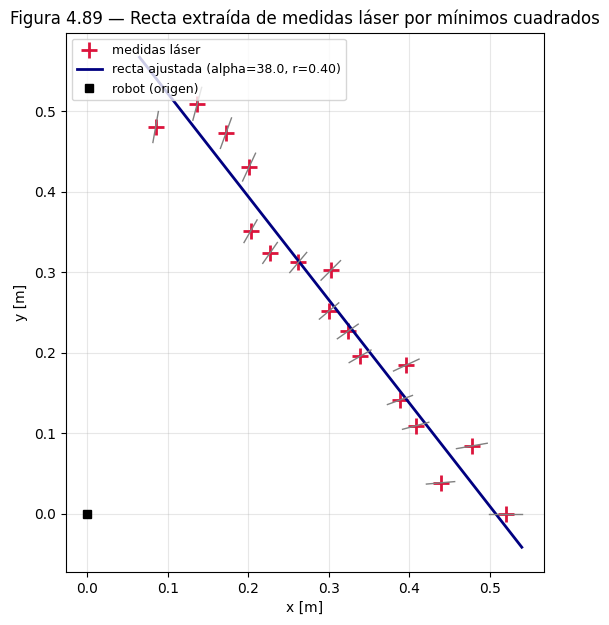

In [ ]:
# Reproducción de la Figura 4.89
fig, ax = plt.subplots()
ax.plot(x_t43, y_t43, '+', color='crimson', markersize=11, mew=2, label='medidas láser')
dibujar_recta(ax, alpha, r, [x_t43.min()-0.02, x_t43.max()+0.02],
              color='navy', lw=2, label=f'recta ajustada (alpha={np.rad2deg(alpha):.1f}, r={r:.2f})')
# barras de incertidumbre (proporcional a la distancia, como en el libro)
for xi, yi, ti, ri in zip(x_t43, y_t43, theta, rho):
    s = 0.04*ri
    ax.plot([xi - s*np.cos(ti), xi + s*np.cos(ti)],
            [yi - s*np.sin(ti), yi + s*np.sin(ti)], color='gray', lw=1)
ax.plot(0, 0, 'ks', label='robot (origen)')
set_eje_igual(ax); ax.legend(loc='upper left', fontsize=9)
ax.set_title('Figura 4.89 — Recta extraída de medidas láser por mínimos cuadrados')
plt.show()

> **Nota didáctica:** obtenemos $r = 0.40$ m exacto y $\alpha \approx 38°$, prácticamente igual al $37.36°$ del libro (la pequeña diferencia viene del redondeo de la tabla). El ajuste por mínimos cuadrados resuelve la **pregunta 3**, pero asume que *todos* los puntos pertenecen a una sola recta. En un escaneo real hay varias paredes y puntos espurios (sillas, personas). Para eso necesitamos los **algoritmos de segmentación**.

## 3. Un escaneo LiDAR simulado (varias paredes + ruido + outliers)

Para probar los algoritmos de segmentación necesitamos un escaneo realista: varias paredes que forman una esquina, ruido gaussiano en el rango y algunos puntos espurios (*outliers*: una persona, una silla). Generamos ese escaneo **en orden angular**, igual que entrega un LiDAR real (importante: varios algoritmos aprovechan ese orden secuencial).

Puntos del escaneo: 188


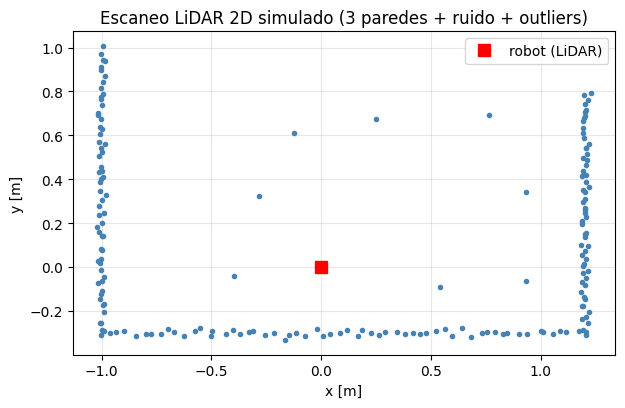

In [ ]:
def generar_escaneo(n_por_pared=60, sigma=0.01, n_outliers=8):
    '''
    Simula un escaneo LiDAR 2D de 3 paredes (forma de U / esquina) con ruido
    y algunos outliers. Devuelve puntos (x, y) ORDENADOS por angulo, como un LiDAR real.
    '''
    segmentos = [((-1.0, 1.0), (-1.0, -0.3)),   # pared izquierda
                 ((-1.0, -0.3), (1.2, -0.3)),    # pared inferior
                 ((1.2, -0.3), (1.2, 0.8))]      # pared derecha
    xs, ys = [], []
    for (x0, y0), (x1, y1) in segmentos:
        t = np.linspace(0, 1, n_por_pared)
        xs.append(x0 + t*(x1-x0)); ys.append(y0 + t*(y1-y0))
    x = np.concatenate(xs); y = np.concatenate(ys)
    x += np.random.normal(0, sigma, x.shape)   # ruido de medida
    y += np.random.normal(0, sigma, y.shape)
    # outliers (objetos que no son pared)
    ox = np.random.uniform(-0.8, 1.0, n_outliers)
    oy = np.random.uniform(-0.1, 0.7, n_outliers)
    x = np.concatenate([x, ox]); y = np.concatenate([y, oy])
    # ordenar por angulo, como un escaner real
    ang = np.arctan2(y, x)
    idx = np.argsort(ang)
    return x[idx], y[idx]

X, Y = generar_escaneo()
print('Puntos del escaneo:', len(X))

fig, ax = plt.subplots()
ax.plot(X, Y, '.', color='steelblue', ms=6)
ax.plot(0, 0, 'rs', ms=9, label='robot (LiDAR)')
set_eje_igual(ax); ax.legend(); ax.set_title('Escaneo LiDAR 2D simulado (3 paredes + ruido + outliers)')
plt.show()

## 4. Algoritmo 1 — Split-and-Merge (Iterative End-Point Fit)

Es el algoritmo de extracción de líneas **más popular** (y el más rápido según la Tabla 4.4). Pseudocódigo del libro:

```
Algoritmo 1: Split-and-Merge
1. Inicio: el conjunto s1 son los N puntos. Poner s1 en una lista L
2. Ajustar una recta al siguiente conjunto s_i de L
3. Detectar el punto P con distancia maxima d_P a la recta
4. Si d_P < umbral -> continuar (ir al paso 2)
5. Si no -> partir s_i en P en s_i1 y s_i2; reemplazar s_i por s_i1 y s_i2; ir a 2
6. Cuando todos los segmentos de L han sido revisados -> fusionar (merge) segmentos colineales
```

En la variante **Iterative-End-Point-Fit (IEPF)** la "recta" no se ajusta por mínimos cuadrados sino que simplemente se traza **uniendo el primer y el último punto** del segmento (más rápido). Es la forma clásica de implementarlo. La idea de *split* es recursiva: parte el segmento donde más se aleja de la cuerda.

---
**Algoritmo del libro:**

![algo1_split_and_merge.png](algo1_split_and_merge.png)


In [ ]:
def _dist_a_segmento(px, py, x0, y0, x1, y1):
    '''Distancia perpendicular del punto P a la recta que pasa por (x0,y0)-(x1,y1).'''
    dx, dy = x1-x0, y1-y0
    norm = np.hypot(dx, dy)
    if norm < 1e-12:
        return np.hypot(px-x0, py-y0)
    # distancia a la recta infinita (formula del producto cruz)
    return abs(dx*(y0-py) - (x0-px)*dy) / norm

def split_and_merge(x, y, umbral=0.03, min_pts=4):
    '''
    Split-and-Merge en su variante Iterative-End-Point-Fit (IEPF).
    Devuelve una lista de segmentos; cada uno es (indices_de_puntos).
    '''
    puntos = list(range(len(x)))
    segmentos = []

    def split(idx):
        if len(idx) < min_pts:
            return
        i0, i1 = idx[0], idx[-1]
        # recta = cuerda entre el primer y ultimo punto (IEPF)
        dmax, kmax = 0.0, -1
        for k in idx[1:-1]:
            d = _dist_a_segmento(x[k], y[k], x[i0], y[i0], x[i1], y[i1])
            if d > dmax:
                dmax, kmax = d, k
        if dmax > umbral and kmax != -1:
            pos = idx.index(kmax)
            split(idx[:pos+1])      # parte izquierda
            split(idx[pos:])        # parte derecha
        else:
            segmentos.append(idx)   # el segmento es suficientemente recto

    split(puntos)
    return segmentos

segs = split_and_merge(X, Y, umbral=0.03)
print('Segmentos encontrados:', len(segs))

Segmentos encontrados: 8


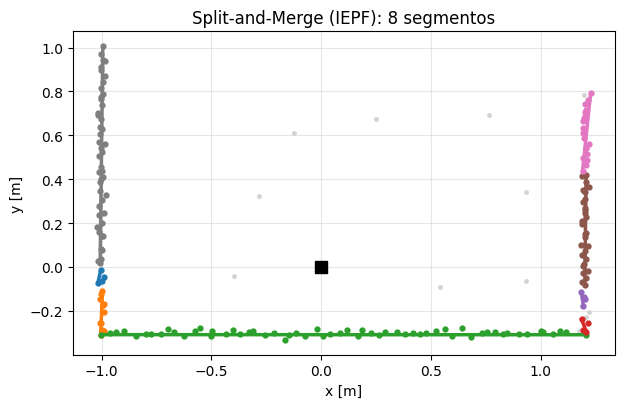

In [ ]:
# Visualizacion de Split-and-Merge: ajustamos una recta LS a cada segmento
fig, ax = plt.subplots()
ax.plot(X, Y, '.', color='lightgray', ms=5)
colores = plt.cm.tab10(np.linspace(0, 1, 10))
for j, idx in enumerate(segs):
    c = colores[j % 10]
    xi, yi = X[list(idx)], Y[list(idx)]
    ax.plot(xi, yi, '.', color=c, ms=7)
    a, rr = ajustar_recta_ls(xi, yi)
    # dibujar el segmento solo entre sus puntos extremos
    ax.plot([xi[0], xi[-1]], [yi[0], yi[-1]], '-', color=c, lw=2.5)
ax.plot(0, 0, 'ks', ms=9)
set_eje_igual(ax); ax.set_title(f'Split-and-Merge (IEPF): {len(segs)} segmentos')
plt.show()

## 5. Algoritmo 3 — Incremental (Line-Tracking)

Muy simple y muy rápido. Aprovecha el orden secuencial del escaneo: va **creciendo** una recta punto a punto mientras el ajuste siga siendo bueno; cuando un punto rompe la condición, cierra la recta y empieza otra.

```
Algoritmo 3: Incremental
1. Empezar con los 2 primeros puntos, construir una recta
2. Anadir el siguiente punto al modelo de recta actual
3. Recalcular los parametros de la recta (line fitting)
4. Si cumple la condicion de recta -> continuar (paso 2)
5. Si no -> devolver el ultimo punto, recalcular la recta, devolver la recta
6. Continuar con los dos puntos siguientes, ir al paso 2
```

---
**Algoritmo del libro:**

![algo3_incremental.png](algo3_incremental.png)


Segmentos (Incremental): 12


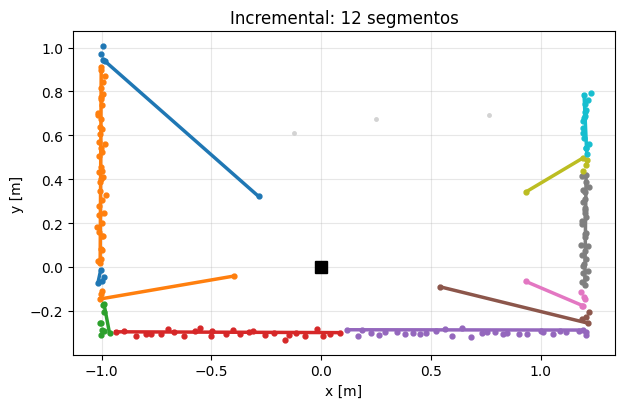

In [ ]:
def incremental(x, y, umbral=0.03, min_pts=4):
    '''
    Algoritmo Incremental (line-tracking). Crece una recta punto a punto
    mientras el error perpendicular maximo se mantenga bajo el umbral.
    Devuelve lista de segmentos (listas de indices).
    '''
    n = len(x)
    segmentos = []
    i = 0
    while i < n - 1:
        idx = [i, i+1]                 # arrancar con 2 puntos
        a, r = ajustar_recta_ls(x[idx], y[idx])
        j = i + 2
        while j < n:
            prueba = idx + [j]
            a, r = ajustar_recta_ls(x[prueba], y[prueba])
            d = np.abs(distancia_punto_recta(x[prueba], y[prueba], a, r))
            if d.max() < umbral:       # el punto cabe en la recta
                idx = prueba
                j += 1
            else:
                break                  # el punto rompe la recta
        if len(idx) >= min_pts:
            segmentos.append(idx)
        i = j                          # seguir con los puntos restantes
    return segmentos

segs_inc = incremental(X, Y, umbral=0.03)
print('Segmentos (Incremental):', len(segs_inc))

fig, ax = plt.subplots()
ax.plot(X, Y, '.', color='lightgray', ms=5)
colores = plt.cm.tab10(np.linspace(0, 1, 10))
for j, idx in enumerate(segs_inc):
    c = colores[j % 10]; xi, yi = X[idx], Y[idx]
    ax.plot(xi, yi, '.', color=c, ms=7)
    ax.plot([xi[0], xi[-1]], [yi[0], yi[-1]], '-', color=c, lw=2.5)
ax.plot(0, 0, 'ks', ms=9)
set_eje_igual(ax); ax.set_title(f'Incremental: {len(segs_inc)} segmentos')
plt.show()

## 6. Algoritmo 4 — RANSAC (RANdom SAmple Consensus)

Método **no determinista** (da resultados distintos en cada corrida) pero muy robusto frente a *outliers* (¡tolera más del 50%!). No aprovecha el orden de los puntos.

```
Algoritmo 4: RANSAC
1. Inicio: A es un conjunto de N puntos
2. repetir
3.   Seleccionar al azar 2 puntos de A
4.   Ajustar una recta por esos 2 puntos
5.   Calcular la distancia de todos los demas puntos a la recta
6.   Construir el conjunto de inliers (puntos con distancia < d)
7.   Guardar esos inliers
8. hasta alcanzar el numero maximo de iteraciones k
9. El conjunto con mas inliers es la solucion
```

**¿Cuántas iteraciones $k$ necesito?** Si $w$ = fracción de inliers y queremos probabilidad $p$ de encontrar un conjunto sin outliers (ec. 4.143):

$$k = \frac{\log(1-p)}{\log\big(1-w^2\big)}$$

Ejemplo del libro: con $p=0.99$ y $w=0.5$ bastan **16 iteraciones**.

---
**Algoritmo del libro:**

![algo4_ransac.png](algo4_ransac.png)


In [ ]:
# Numero de iteraciones segun la ecuacion 4.143
def iteraciones_ransac(p, w):
    return np.log(1 - p) / np.log(1 - w**2)

print('p=0.99, w=0.50 ->', np.ceil(iteraciones_ransac(0.99, 0.50)), 'iteraciones (libro: 16)')
print('p=0.99, w=0.30 ->', np.ceil(iteraciones_ransac(0.99, 0.30)), 'iteraciones')

p=0.99, w=0.50 -> 17.0 iteraciones (libro: 16)
p=0.99, w=0.30 -> 49.0 iteraciones


Rectas extraidas por RANSAC: 3


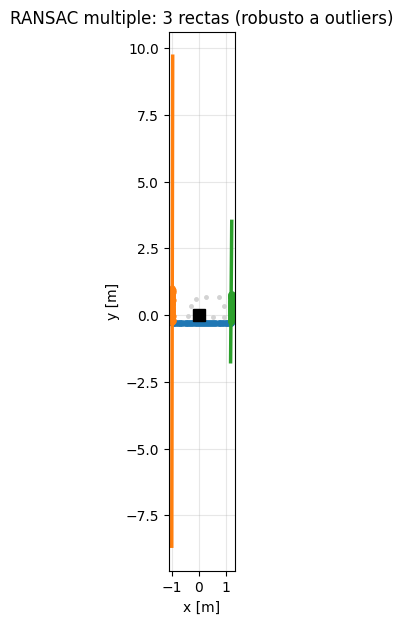

In [ ]:
def ransac_una_recta(x, y, d=0.02, k=200):
    '''
    RANSAC para extraer UNA recta: la que reune mas inliers.
    d : umbral de distancia para considerar un punto inlier.
    k : numero de iteraciones.
    Devuelve (alpha, r, mascara_inliers).
    '''
    n = len(x); mejor_inliers = np.zeros(n, bool); mejor = (0.0, 0.0)
    for _ in range(k):
        i, j = np.random.choice(n, 2, replace=False)
        if np.hypot(x[i]-x[j], y[i]-y[j]) < 1e-6:
            continue
        a, r = ajustar_recta_ls(x[[i, j]], y[[i, j]])
        dist = np.abs(distancia_punto_recta(x, y, a, r))
        inliers = dist < d
        if inliers.sum() > mejor_inliers.sum():
            mejor_inliers = inliers; mejor = (a, r)
    # reajustar la recta con todos sus inliers (mas preciso)
    a, r = ajustar_recta_ls(x[mejor_inliers], y[mejor_inliers])
    return a, r, mejor_inliers

def ransac_multiple(x, y, d=0.02, k=200, min_inliers=15, max_rectas=6):
    '''Extrae varias rectas: corre RANSAC, quita sus inliers y repite.'''
    x = x.copy(); y = y.copy()
    rectas = []
    for _ in range(max_rectas):
        if len(x) < min_inliers:
            break
        a, r, inl = ransac_una_recta(x, y, d, k)
        if inl.sum() < min_inliers:
            break
        rectas.append((a, r, x[inl].copy(), y[inl].copy()))
        x, y = x[~inl], y[~inl]      # quitar inliers y seguir
    return rectas

rectas = ransac_multiple(X, Y, d=0.02, k=300)
print('Rectas extraidas por RANSAC:', len(rectas))

fig, ax = plt.subplots()
ax.plot(X, Y, '.', color='lightgray', ms=5)
colores = plt.cm.tab10(np.linspace(0, 1, 10))
for j, (a, r, xi, yi) in enumerate(rectas):
    c = colores[j % 10]
    ax.plot(xi, yi, '.', color=c, ms=7)
    dibujar_recta(ax, a, r, [xi.min(), xi.max()], color=c, lw=2.5)
ax.plot(0, 0, 'ks', ms=9)
set_eje_igual(ax); ax.set_title(f'RANSAC multiple: {len(rectas)} rectas (robusto a outliers)')
plt.show()

## 7. Algoritmo 5 — Transformada de Hough

Cada punto $(x_i, y_i)$ "vota" por **todas** las rectas que podrían pasar por él. En el espacio de parámetros $(\alpha, r)$ esos votos son una curva sinusoidal $r = x_i\cos\alpha + y_i\sin\alpha$. Donde muchas curvas se cruzan (acumulador con muchos votos) hay una recta real.

```
Algoritmo 5: Transformada de Hough
1. Inicio: A es un conjunto de N puntos
2. Inicializar el acumulador a 0
3. Construir los votos en el acumulador
4. Elegir la celda con mas votos V_max
5. Si V_max < umbral -> terminar
6. Si no -> determinar los inliers de esa celda
7. Ajustar una recta a los inliers y guardarla
8. Quitar los inliers del conjunto, ir al paso 2
```

Desventajas (libro): elegir el tamaño de celda es difícil y no modela bien el ruido. Mejora: en el paso 7 reajustar con mínimos cuadrados.

---
**Algoritmo del libro:**

![algo5_hough_transform.png](algo5_hough_transform.png)


Rectas extraidas por Hough: 3


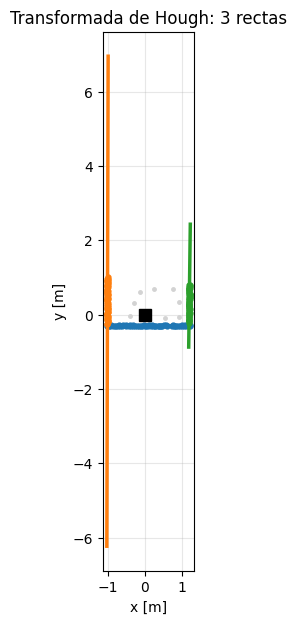

In [ ]:
def hough_lineas(x, y, n_alpha=180, n_r=200, umbral_votos=20,
                 d_inlier=0.02, max_rectas=6):
    '''
    Transformada de Hough para rectas en forma polar (alpha, r).
    Construye el acumulador, extrae picos y ajusta rectas a sus inliers.
    '''
    alphas = np.linspace(-np.pi/2, np.pi/2, n_alpha)
    r_max = np.hypot(x, y).max() * 1.05
    r_edges = np.linspace(-r_max, r_max, n_r+1)
    cos_a, sin_a = np.cos(alphas), np.sin(alphas)

    disponibles = np.ones(len(x), bool)
    rectas = []
    for _ in range(max_rectas):
        xi, yi = x[disponibles], y[disponibles]
        if len(xi) < umbral_votos:
            break
        # acumulador: para cada punto y cada alpha, r = x cos a + y sin a
        R = np.outer(xi, cos_a) + np.outer(yi, sin_a)          # (n_pts, n_alpha)
        acc = np.zeros((n_alpha, n_r), int)
        for ja in range(n_alpha):
            bins = np.digitize(R[:, ja], r_edges) - 1
            bins = bins[(bins >= 0) & (bins < n_r)]
            np.add.at(acc[ja], bins, 1)
        ja, jr = np.unravel_index(np.argmax(acc), acc.shape)
        if acc[ja, jr] < umbral_votos:
            break
        a = alphas[ja]; r = 0.5*(r_edges[jr] + r_edges[jr+1])
        # inliers globales de esa recta
        dist = np.abs(distancia_punto_recta(x, y, a, r))
        inl = disponibles & (dist < d_inlier)
        if inl.sum() < umbral_votos:
            disponibles &= ~inl
            continue
        a, r = ajustar_recta_ls(x[inl], y[inl])     # reajuste fino
        rectas.append((a, r, x[inl].copy(), y[inl].copy()))
        disponibles &= ~inl
    return rectas

rectas_h = hough_lineas(X, Y)
print('Rectas extraidas por Hough:', len(rectas_h))

fig, ax = plt.subplots()
ax.plot(X, Y, '.', color='lightgray', ms=5)
for j, (a, r, xi, yi) in enumerate(rectas_h):
    c = plt.cm.tab10(j % 10)
    ax.plot(xi, yi, '.', color=c, ms=7)
    dibujar_recta(ax, a, r, [xi.min(), xi.max()], color=c, lw=2.5)
ax.plot(0, 0, 'ks', ms=9)
set_eje_igual(ax); ax.set_title(f'Transformada de Hough: {len(rectas_h)} rectas')
plt.show()

## 8. Algoritmo 2 — Line-Regression (ventana deslizante)

Usa una **ventana deslizante** de tamaño $N_f$ (típicamente $N_f = 7$). En cada paso ajusta una recta a los $N_f$ puntos de la ventana, avanza un punto y repite. Luego mide qué tan parecidas son ventanas vecinas (distancia de Mahalanobis) y agrupa las que pertenecen a la misma recta.

```
Algoritmo 2: Line-Regression
1. Inicializar el tamano de ventana N_f
2. Ajustar una recta a cada N_f puntos consecutivos
3. Calcular un "array de fidelidad": suma de distancias de Mahalanobis entre ventanas vecinas
4. Construir segmentos buscando elementos consecutivos con valor < umbral
5. Fusionar segmentos solapados y recalcular parametros
```

Aquí lo implementamos con una versión simplificada de la "fidelidad": comparamos el ángulo $\alpha$ de ventanas vecinas (si el ángulo cambia poco, es la misma pared).

---
**Algoritmo del libro:**

![algo2_line_regression.png](algo2_line_regression.png)


Segmentos (Line-Regression): 23


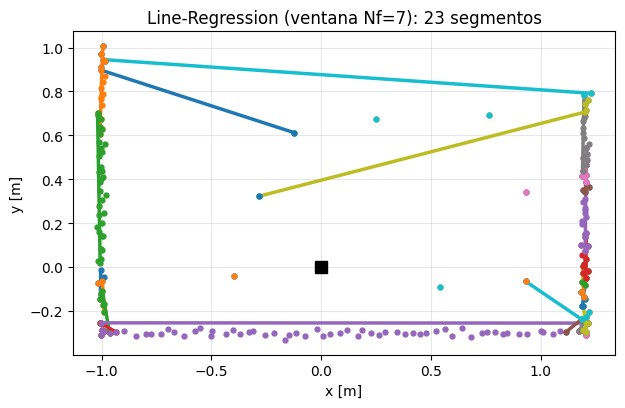

In [ ]:
def line_regression(x, y, Nf=7, umbral_ang=np.deg2rad(10), min_pts=5):
    '''
    Line-Regression simplificado con ventana deslizante.
    1) ajusta una recta a cada Nf puntos consecutivos
    2) agrupa ventanas vecinas cuyo angulo alpha se parece
    Devuelve segmentos (listas de indices).
    '''
    n = len(x)
    if n < Nf:
        return []
    angs = []
    for i in range(n - Nf + 1):
        a, _ = ajustar_recta_ls(x[i:i+Nf], y[i:i+Nf])
        angs.append(a)
    angs = np.array(angs)
    segmentos = []; ini = 0
    for i in range(1, len(angs)):
        dif = np.abs(np.arctan2(np.sin(angs[i]-angs[i-1]), np.cos(angs[i]-angs[i-1])))
        if dif > umbral_ang:
            idx = list(range(ini, i-1 + Nf))
            if len(idx) >= min_pts: segmentos.append(idx)
            ini = i
    idx = list(range(ini, len(angs)-1 + Nf))
    if len(idx) >= min_pts: segmentos.append(idx)
    return segmentos

segs_lr = line_regression(X, Y, Nf=7)
print('Segmentos (Line-Regression):', len(segs_lr))

fig, ax = plt.subplots()
ax.plot(X, Y, '.', color='lightgray', ms=5)
for j, idx in enumerate(segs_lr):
    c = plt.cm.tab10(j % 10); xi, yi = X[idx], Y[idx]
    ax.plot(xi, yi, '.', color=c, ms=7)
    ax.plot([xi[0], xi[-1]], [yi[0], yi[-1]], '-', color=c, lw=2.5)
ax.plot(0, 0, 'ks', ms=9)
set_eje_igual(ax); ax.set_title(f'Line-Regression (ventana Nf=7): {len(segs_lr)} segmentos')
plt.show()

## 9. Algoritmo 6 — Expectation-Maximization (EM)

Método **probabilístico** y **no determinista**. Alterna dos pasos hasta converger:
- **E-step**: dado el modelo de recta, calcula un *peso* para cada punto (qué tan probable es que pertenezca a la recta).
- **M-step**: dado los pesos, reajusta los parámetros de la recta (mínimos cuadrados ponderado).

```
Algoritmo 6: Expectation-Maximization
1. Inicio: A es un conjunto de N puntos
2. repetir
3.   Generar al azar parametros para una recta
4.   Inicializar pesos de los puntos restantes
5.   repetir
6.     E-Step: calcular los pesos de los puntos dado el modelo de recta
7.     M-Step: recalcular los parametros de la recta
8.   hasta max. pasos o convergencia
9. hasta max. intentos o se encuentra una recta
10. Si se encontro -> guardar la recta, quitar inliers, ir al paso 2
11. Si no -> terminar
```

Desventajas: puede caer en mínimos locales y es lento. Lo implementamos para **una** recta usando pesos gaussianos $w_i = \exp(-d_i^2 / 2\sigma^2)$.

---
**Algoritmo del libro:**

![algo6_expectation_maximization.png](algo6_expectation_maximization.png)


EM (una recta) -> inliers: 67


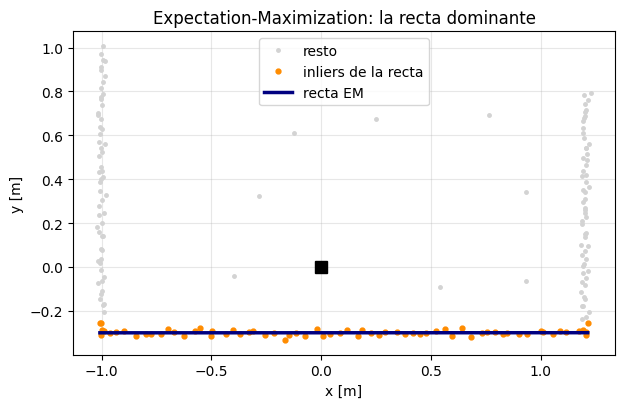

In [ ]:
def em_una_recta(x, y, sigma=0.02, n_iter=30, init=None):
    '''
    EM para ajustar UNA recta. Pesos gaussianos sobre la distancia perpendicular.
    E-step: w_i = exp(-d_i^2 / (2 sigma^2))
    M-step: ajuste de recta ponderado por w_i
    '''
    if init is None:
        i, j = np.random.choice(len(x), 2, replace=False)
        a, r = ajustar_recta_ls(x[[i, j]], y[[i, j]])
    else:
        a, r = init
    for _ in range(n_iter):
        d = distancia_punto_recta(x, y, a, r)
        w = np.exp(-(d**2) / (2*sigma**2))
        if w.sum() < 1e-9:
            break
        a, r = ajustar_recta_ls(x, y, w=w)
    d = np.abs(distancia_punto_recta(x, y, a, r))
    inliers = d < 3*sigma
    return a, r, inliers

mejor = None
for _ in range(20):
    a, r, inl = em_una_recta(X, Y, sigma=0.02)
    if mejor is None or inl.sum() > mejor[2].sum():
        mejor = (a, r, inl)
a, r, inl = mejor
print('EM (una recta) -> inliers:', int(inl.sum()))

fig, ax = plt.subplots()
ax.plot(X, Y, '.', color='lightgray', ms=5, label='resto')
ax.plot(X[inl], Y[inl], '.', color='darkorange', ms=7, label='inliers de la recta')
dibujar_recta(ax, a, r, [X[inl].min(), X[inl].max()], color='navy', lw=2.5, label='recta EM')
ax.plot(0, 0, 'ks', ms=9)
set_eje_igual(ax); ax.legend(); ax.set_title('Expectation-Maximization: la recta dominante')
plt.show()

## 10. Detalles de implementación: *Clustering* y *Merging*

El libro recuerda dos pasos prácticos que envuelven a cualquiera de los 6 algoritmos:

- **Clustering (pre-proceso):** antes de extraer líneas se separan los puntos en grupos buscando **saltos grandes** en la distancia radial entre puntos consecutivos (un salto = un borde / objeto distinto). Los grupos con muy pocos puntos se descartan (ruido, personas).
- **Merging (post-proceso):** por oclusiones, una misma pared puede salir como **varios segmentos**. Si dos segmentos consecutivos tienen distancia de Mahalanobis pequeña, se **fusionan** y se recalculan sus parámetros. Se aplica a la salida de todos los algoritmos.

Clusters tras pre-proceso: 6 | tamanos: [4, 76, 5, 29, 20, 46]


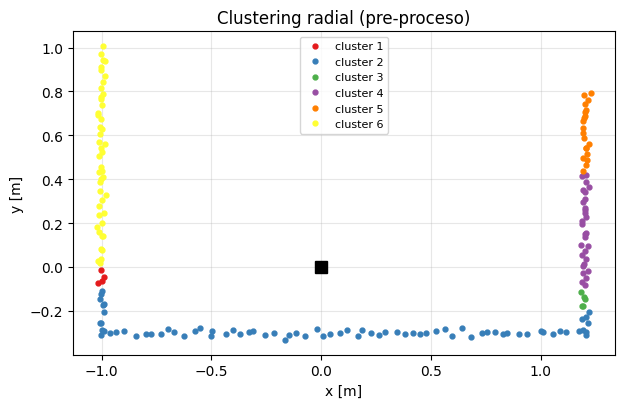

In [ ]:
def clustering_radial(x, y, salto=0.15, min_pts=4):
    '''
    Separa el escaneo en clusters buscando saltos en la distancia radial
    entre puntos consecutivos (ya ordenados por angulo). Descarta clusters chicos.
    '''
    rad = np.hypot(x, y)
    clusters = []; actual = [0]
    for i in range(1, len(x)):
        if abs(rad[i] - rad[i-1]) > salto:
            if len(actual) >= min_pts: clusters.append(actual)
            actual = [i]
        else:
            actual.append(i)
    if len(actual) >= min_pts: clusters.append(actual)
    return clusters

cl = clustering_radial(X, Y, salto=0.15)
print('Clusters tras pre-proceso:', len(cl), '| tamanos:', [len(c) for c in cl])

fig, ax = plt.subplots()
for j, idx in enumerate(cl):
    ax.plot(X[idx], Y[idx], '.', color=plt.cm.Set1(j % 9), ms=7, label=f'cluster {j+1}')
ax.plot(0, 0, 'ks', ms=9)
set_eje_igual(ax); ax.legend(fontsize=8); ax.set_title('Clustering radial (pre-proceso)')
plt.show()

## 11. Comparación de los seis algoritmos (Tabla 4.4)

Estudio de Nguyen et al. sobre un escaneo de $N=722$ puntos. $S$ = nº de segmentos extraídos, $N_f$ = ventana, $N_{Trials}$ = nº de pruebas RANSAC, $N_C,N_R$ = columnas/filas del acumulador de Hough.

| Algoritmo | Complejidad | Velocidad [Hz] | Falsos positivos | Precisión | Tipo |
|---|---|---|---|---|---|
| **Split-and-Merge** | $N\log N$ | **1500** | 10% | +++ | determinista |
| **Incremental** | $S\cdot N$ | 600 | **6%** | +++ | determinista |
| **Line-Regression** | $N\cdot N_f$ | 400 | 10% | +++ | determinista |
| **RANSAC** | $S\cdot N\cdot N_{Trials}$ | 30 | 30% | ++++ | no determinista |
| **Hough** | $S\cdot N\cdot N_C\cdot N_R + S\cdot N_C\cdot N_R$ | 10 | 30% | ++++ | determinista |
| **Expectation-Maximization** | $S\cdot N\cdot N_1\cdot N_2$ | 1 | 50% | ++++ | no determinista |

**Conclusiones del libro:**
- **Split-and-Merge** e **Incremental** son los mejores en **rapidez + correctitud** → la mejor opción para localización y mapeo con láser 2D (lo que usaremos en CapyTown).
- **RANSAC, Hough y EM** son más **precisos** (eliminan outliers) pero generan **más falsos positivos**, porque no aprovechan el orden secuencial del escaneo, y son más lentos.
- La elección final depende de la aplicación y de la precisión deseada.

## 12. Conexión con ROS2 y CapyTown

En el robot Yahboom (Pi5) el LiDAR publica en el tópico `/scan` un mensaje **`sensor_msgs/msg/LaserScan`** con, entre otros campos:

- `ranges`: lista de distancias $\rho_i$ (en metros),
- `angle_min`, `angle_increment`: para reconstruir el ángulo $\theta_i = \text{angle\_min} + i\cdot\text{angle\_increment}$,
- `range_min`, `range_max`: distancias válidas.

El puente entre el LiDAR real y todo el código de este notebook es **convertir `LaserScan` a puntos $(x,y)$** y pasarlos a cualquiera de los algoritmos. Este es el esqueleto de un nodo:

In [ ]:
# Esqueleto de nodo ROS2 (solo se imprime; va en el Yahboom dentro de un paquete ROS2)
codigo_ros2 = r'''
import rclpy
from rclpy.node import Node
from sensor_msgs.msg import LaserScan
import numpy as np

class ExtractorLineas(Node):
    def __init__(self):
        super().__init__("extractor_lineas")
        self.sub = self.create_subscription(LaserScan, "/scan", self.cb, 10)

    def laserscan_a_xy(self, msg):
        # Convierte un LaserScan a un array de puntos (x, y) validos
        ang = msg.angle_min + np.arange(len(msg.ranges)) * msg.angle_increment
        rho = np.array(msg.ranges)
        valido = np.isfinite(rho) & (rho > msg.range_min) & (rho < msg.range_max)
        ang, rho = ang[valido], rho[valido]
        return rho*np.cos(ang), rho*np.sin(ang)

    def cb(self, msg):
        x, y = self.laserscan_a_xy(msg)
        # 1) pre-proceso: clustering_radial(x, y)
        # 2) extraer lineas: split_and_merge(x, y, umbral=0.03)
        # 3) usar las rectas (alpha, r) para localizacion / evitar paredes
        segs = split_and_merge(x, y, umbral=0.03)
        self.get_logger().info(f"{len(segs)} segmentos detectados")

def main():
    rclpy.init(); rclpy.spin(ExtractorLineas()); rclpy.shutdown()
'''
print(codigo_ros2)


import rclpy
from rclpy.node import Node
from sensor_msgs.msg import LaserScan
import numpy as np

class ExtractorLineas(Node):
    def __init__(self):
        super().__init__("extractor_lineas")
        self.sub = self.create_subscription(LaserScan, "/scan", self.cb, 10)

    def laserscan_a_xy(self, msg):
        # Convierte un LaserScan a un array de puntos (x, y) validos
        ang = msg.angle_min + np.arange(len(msg.ranges)) * msg.angle_increment
        rho = np.array(msg.ranges)
        valido = np.isfinite(rho) & (rho > msg.range_min) & (rho < msg.range_max)
        ang, rho = ang[valido], rho[valido]
        return rho*np.cos(ang), rho*np.sin(ang)

    def cb(self, msg):
        x, y = self.laserscan_a_xy(msg)
        # 1) pre-proceso: clustering_radial(x, y)
        # 2) extraer lineas: split_and_merge(x, y, umbral=0.03)
        # 3) usar las rectas (alpha, r) para localizacion / evitar paredes
        segs = split_and_merge(x, y, umbral=0.03)
        self.get_logger().inf

## 13. Ejercicios para los estudiantes

1. **Sensibilidad al umbral.** Corre `split_and_merge` con `umbral` = 0.01, 0.03, 0.08. ¿Cómo cambia el número de segmentos? Explica el compromiso entre sobre-segmentar y unir paredes distintas.
2. **Ruido.** Aumenta `sigma` en `generar_escaneo` (0.01 → 0.05). ¿Qué algoritmo aguanta mejor el ruido: Split-and-Merge o RANSAC? Justifica con las imágenes.
3. **Outliers.** Sube `n_outliers` a 30. Compara Incremental (determinista, usa el orden) vs RANSAC (robusto a outliers). ¿Cuál falla y por qué?
4. **Iteraciones de RANSAC.** Con la ecuación 4.143, ¿cuántas iteraciones $k$ necesitas para $p=0.999$ y $w=0.4$? Verifica empíricamente bajando `k` hasta que RANSAC empiece a fallar.
5. **Hough.** Cambia la resolución del acumulador (`n_alpha`, `n_r`). ¿Cómo afecta la precisión y la velocidad? Relaciónalo con la desventaja que menciona el libro.
6. **Mínimos cuadrados.** Toma un solo segmento detectado y ajústalo con `ajustar_recta_ls`. Compara la recta LS con la cuerda primer-último punto del IEPF. ¿Cuándo difieren más?
7. **Reto CapyTown.** Graba un `/scan` real del Yahboom (`ros2 bag record /scan`), conviértelo con `laserscan_a_xy` y extrae las paredes de una "manzana" del circuito. ¿Sirve para que el robot se alinee con la pared?

---

### Referencia
Siegwart, Nourbakhsh & Scaramuzza, *Introduction to Autonomous Mobile Robots* (2ª ed.), MIT Press — Cap. 4.7 *Feature Extraction Based on Range Data*.